In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [127]:
US_PATH = "/Users/pablo/Desktop/Repositorio_Curso/archive/comprehensive_foods_usda.csv"
GL_PATH = "/Users/pablo/Desktop/Repositorio_Curso/archive/foods_health_scores_allergens.csv"
#Dataset de US y dataset Global

df_us = pd.read_csv(US_PATH)
df_gl = pd.read_csv(GL_PATH)

In [128]:
df_us.head()

,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,...,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


In [129]:
df_gl.head()

,product_name,brands,categories,ingredients,nutriscore_grade,nova_group,ecoscore_grade,allergens,energy_kcal,fat_100g,...,proteins_100g,salt_100g,sodium_100g,contains_gluten,contains_dairy,contains_nuts,contains_soy,contains_eggs,contains_fish,food_type
0,Sidi Ali,سيدي علي,"en:beverages-and-beverages-preparations, en:be...",OBD1 999 999 1112606 266963207 mb,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000000,0.000000,False,False,False,False,False,False,Branded/Packaged
1,Perly,Perly,"en:dairies, en:fermented-foods, en:fermented-m...","milk cream, cream, sugar, banana, bacteria",UNKNOWN,3.0,B,"en:banana, en:milk",97.0,3.0,...,8.0,NaN,NaN,False,True,False,False,False,False,Branded/Packaged
2,Sidi Ali,Sidi Ali,"en:beverages-and-beverages-preparations, en:be...","Sodium, Calcium, Magnésium, Potassium, Bicarbo...",A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
3,Eau minérale naturelle,sidi ali,"en:beverages-and-beverages-preparations, en:be...",100% mineral water,A,1.0,NOT-APPLICABLE,NaN,NaN,NaN,...,NaN,0.065000,0.026000,False,False,False,False,False,False,Branded/Packaged
4,اكوافينا,AQUAFINA,"en:beverages-and-beverages-preparations, en:be...",ouverture et avant le : Voir bouteille. après ...,A,NaN,NOT-APPLICABLE,NaN,0.0,0.0,...,0.0,0.000508,0.000203,False,False,False,False,False,False,Branded/Packaged


In [130]:
df_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fdc_id             40000 non-null  int64  
 1   food_name          40000 non-null  object 
 2   data_type          40000 non-null  object 
 3   food_category      39954 non-null  object 
 4   brand_owner        31383 non-null  object 
 5   brand_name         30254 non-null  object 
 6   ingredients        31656 non-null  object 
 7   serving_size       31842 non-null  float64
 8   serving_unit       31842 non-null  object 
 9   household_serving  30790 non-null  object 
 10  calories           39538 non-null  float64
 11  carbs_g            39411 non-null  float64
 12  calcium_mg         34215 non-null  float64
 13  fat_g              39713 non-null  float64
 14  protein_g          39747 non-null  float64
 15  saturated_fat_g    35014 non-null  float64
 16  vitamin_c_mg       229

In [131]:
df_gl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_name        4785 non-null   object 
 1   brands              4751 non-null   object 
 2   categories          4913 non-null   object 
 3   ingredients         4797 non-null   object 
 4   nutriscore_grade    4983 non-null   object 
 5   nova_group          4522 non-null   float64
 6   ecoscore_grade      4984 non-null   object 
 7   allergens           3332 non-null   object 
 8   energy_kcal         4682 non-null   float64
 9   fat_100g            4695 non-null   float64
 10  saturated_fat_100g  4617 non-null   float64
 11  carbs_100g          4676 non-null   float64
 12  sugars_100g         4631 non-null   float64
 13  fiber_100g          3495 non-null   float64
 14  proteins_100g       4690 non-null   float64
 15  salt_100g           4653 non-null   float64
 16  sodium

In [132]:
#Primero vamos a comparar de ambos sets, productos envasados o de marcas, para comparar lo mismo de ambas partes, ya que si no
#no sería una comparación justa ni equilibrada.
#Debemos de entender que aquellos productos que son branded, suelen ser productos envasados, con su marca, con su etiqueta y 
#más o menos procesados.

gl_pack = df_gl[df_gl["food_type"] == "Branded/Packaged"].copy()
us_pack = df_us[df_us["data_type"] == "Branded"].copy()

print("Global envasado:", gl_pack.shape)
print("US envasado:", us_pack.shape)

Global envasado: (4997, 24)
US envasado: (31842, 24)


In [133]:
#visualizamos las unidades de medida y medidas del df de US, ya que las globales están 
#estandarizadas a 100g

us_pack[["food_name","brand_name","brand_owner","serving_size","serving_unit"]].head(12)

,food_name,brand_name,brand_owner,serving_size,serving_unit
8158,AdvancePierre Flamebroiled Rib Shaped Pork Pa...,Advance Pierre,Tyson Foods Inc.,100.0,GRM
8159,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,GOLDEN PLATTER,Golden Platter Foods Inc.,85.0,GRM
8160,ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE...,HERITAGE SELECT,SLT Foods Inc.,46.0,GRM
8161,ARTISANAL COLLECTION SPAGHETTI PASTA,BARILLA,Barilla G & R F.Lli S.P.A.,56.0,GRM
8162,AUTHENTIC BARREL RIPENED FETA CHEESE,APHRODITE,"Wdh, LLC",28.0,GRM
8163,BERRY NUT BLEND BREAKFAST IN THE GO!,EMERALD,"Snyder's-Lance, Inc.",42.5,g
8164,"BLACK CHERRY PURE ENERGY SELTZER, BLACK CHERRY",TRUE NORTH,Energy Beverages LLC,355.0,MLT
8165,BLUE LAKE CUT GREEN BEANS,DEL MONTE,Del Monte Foods Inc.,121.0,GRM
8166,BRIE TRIPLE CRME SOFT-RIPENED CHEESE,PRSIDENT,Besnier S.A.,28.0,GRM
8167,BUFFALO STYLE WHIPPED CREAM CHEESE SPREAD,PHILADELPHIA,Kraft Heinz Foods Company,22.0,GRM


In [134]:
us_pack["serving_unit"].astype("string").str.lower().value_counts().head(10)

#Para ver las más frecuentes
#Tenemos un dataset muy amplio en US, así que esto nos ayuda a poder seleccionar únicamente
#las filas que están medidas en gramos. De esta manera comaparamos lo mismo y hacemos un análisis coherente

serving_unit
g      18531
grm     6999
ml      4420
mlt     1434
mg       291
iu       127
gm        31
mc         9
Name: count, dtype: Int64

In [135]:
us_g = us_pack[us_pack["serving_unit"].astype("string").str.lower().isin(["g","grm","gm"])].copy()
us_g["serving_size"] = pd.to_numeric(us_g["serving_size"], errors="coerce")
us_g = us_g[us_g["serving_size"] > 0].copy()

# Pasamos todo a "por 100g"
us_100g = us_g.copy()
us_100g["energy_kcal_100g"] = (us_100g["calories"] / us_100g["serving_size"]) * 100
us_100g["proteins_100g"] = (us_100g["protein_g"] / us_100g["serving_size"]) * 100
us_100g["fat_100g"] = (us_100g["fat_g"] / us_100g["serving_size"]) * 100
us_100g["carbs_100g"] = (us_100g["carbs_g"] / us_100g["serving_size"]) * 100
us_100g["fiber_100g"] = (us_100g["fiber_g"] / us_100g["serving_size"]) * 100
us_100g["sugars_100g"] = (us_100g["sugar_g"] / us_100g["serving_size"]) * 100

print("US en gramos:", us_g.shape)
print("US convertido a 100g:", us_100g.shape)

us_100g[["food_name","brand_name","serving_size","serving_unit","energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]].head()

US en gramos: (25549, 24)
US convertido a 100g: (25549, 30)


,food_name,brand_name,serving_size,serving_unit,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
8158,AdvancePierre Flamebroiled Rib Shaped Pork Pa...,Advance Pierre,100.0,GRM,209.000000,14.800000,12.100000,10.200000,0.990000,8.180000
8159,ALL NATURAL GLUTEN FREE CHICKEN NUGGETS,GOLDEN PLATTER,85.0,GRM,228.235294,22.117647,11.070588,9.694118,0.000000,0.000000
8160,ALL NATURAL ROSEMARY & OLIVE OIL BASMATI RICE...,HERITAGE SELECT,46.0,GRM,708.695652,14.173913,0.000000,170.217391,4.782609,0.000000
8161,ARTISANAL COLLECTION SPAGHETTI PASTA,BARILLA,56.0,GRM,637.500000,25.535714,3.196429,130.714286,3.571429,3.196429
8162,AUTHENTIC BARREL RIPENED FETA CHEESE,APHRODITE,28.0,GRM,1021.428571,51.071429,89.285714,0.000000,0.000000,0.000000


In [136]:
#Tenemos más columnas porque hemos hecho toda la conversión a 100g, incluyendo de los macro y micronutrientes del datafgrame

In [137]:
#en el dataset Global (gl_pack) la columna calorías se llama todavía 'energy_kcal'así que la renombraremos

gl_pack["energy_kcal_100g"] = gl_pack["energy_kcal"]

In [138]:
print("energy_kcal_100g en GL:", "energy_kcal_100g" in gl_pack.columns)
print("proteins_100g en GL:", "proteins_100g" in gl_pack.columns)
print("fat_100g en GL:", "fat_100g" in gl_pack.columns)
print("carbs_100g en GL:", "carbs_100g" in gl_pack.columns)
print("fiber_100g en GL:", "fiber_100g" in gl_pack.columns)
print("sugars_100g en GL:", "sugars_100g" in gl_pack.columns)

energy_kcal_100g en GL: True
proteins_100g en GL: True
fat_100g en GL: True
carbs_100g en GL: True
fiber_100g en GL: True
sugars_100g en GL: True


In [139]:
us_nutri = us_100g[["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]].copy()
gl_nutri = gl_pack[["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]].copy()

print("US nutrientes:", us_nutri.shape)
print("GL nutrientes:", gl_nutri.shape)

US nutrientes: (25549, 6)
GL nutrientes: (4997, 6)


In [140]:
#Ahora ya tenemos todo organizando y estamos comparando exactamente lo mismo de ambos dataframes

In [141]:
us_nutri.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,2.517200e+04,25359.000000,25342.000000,2.507800e+04,22691.000000,2.399400e+04
mean,1.694733e+03,35.304347,64.192246,2.673903e+02,22.668542,1.353247e+02
std,5.239352e+04,1025.259365,1498.039327,9.549687e+03,1162.152999,7.218706e+03
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,1.388007e+02,1.744493,0.666667,7.084239e+00,0.000000,0.000000e+00
50%,6.236842e+02,11.769912,10.483749,5.100000e+01,1.500000,8.987662e+00
75%,1.403571e+03,24.666667,57.273772,1.731579e+02,11.000000,5.479861e+01
max,7.520000e+06,152000.000000,234000.000000,1.232000e+06,172941.174652,1.112000e+06


In [142]:
gl_nutri.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,4682.000000,4690.000000,4695.000000,4676.000000,3.495000e+03,4631.000000
mean,301.225402,7.348264,15.997065,32.598284,1.748567e+09,12.368927
std,221.661070,11.135688,21.974815,133.906873,1.033727e+11,22.020440
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,99.000000,1.700000,1.500000,4.800000,5.000000e-01,1.095000
50%,295.000000,6.300000,7.420000,19.700000,3.000000e+00,4.300000
75%,456.000000,9.600000,23.000000,58.000000,6.600000e+00,16.000000
max,5280.000000,597.000000,554.000000,8989.000000,6.111242e+12,895.000000


In [143]:
#nos dan resultados desorbitados y poco lógicos. Parece que se debe a alimentos mal registrados.
#esto puede ocurrir por poner comas y puntos sin una estandarización, filas rotas, valores mal registrados,e tc
#vamos a eliminar aquellas filas o registros que no tengan sentido

In [144]:
cols = ["proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

print("US calorías > 1000:", (us_nutri["energy_kcal_100g"] > 1000).sum())
print("US algún macro > 100:", (us_nutri[cols] > 100).any(axis=1).sum())
print("US algún valor < 0:", (us_nutri[["energy_kcal_100g"] + cols] < 0).any(axis=1).sum())

print("GL calorías > 1000:", (gl_nutri["energy_kcal_100g"] > 1000).sum())
print("GL algún macro > 100:", (gl_nutri[cols] > 100).any(axis=1).sum())
print("GL algún valor < 0:", (gl_nutri[["energy_kcal_100g"] + cols] < 0).any(axis=1).sum())

US calorías > 1000: 9461
US algún macro > 100: 12241
US algún valor < 0: 0
GL calorías > 1000: 2
GL algún macro > 100: 5
GL algún valor < 0: 0


In [145]:
#justamente los valores que menos sentido tenían en el .describe eran los de us, como vemos, hay alimentos
#registrados con más de 1000kcal por 100g, y son demasiados. 
#aquí vemos la importancia de tener una recopilación de datos estandarizada y hacer registros correctamente

In [146]:
cols_all = ["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

us_nutri_clean = us_nutri.dropna(subset=cols_all).copy()
gl_nutri_clean = gl_nutri.dropna(subset=cols_all).copy()

us_nutri_clean = us_nutri_clean[
    us_nutri_clean["energy_kcal_100g"].between(0, 1000) &
    us_nutri_clean["proteins_100g"].between(0, 100) &
    us_nutri_clean["fat_100g"].between(0, 100) &
    us_nutri_clean["carbs_100g"].between(0, 100) &
    us_nutri_clean["fiber_100g"].between(0, 100) &
    us_nutri_clean["sugars_100g"].between(0, 100)
].copy()

gl_nutri_clean = gl_nutri_clean[
    gl_nutri_clean["energy_kcal_100g"].between(0, 1000) &
    gl_nutri_clean["proteins_100g"].between(0, 100) &
    gl_nutri_clean["fat_100g"].between(0, 100) &
    gl_nutri_clean["carbs_100g"].between(0, 100) &
    gl_nutri_clean["fiber_100g"].between(0, 100) &
    gl_nutri_clean["sugars_100g"].between(0, 100)
].copy()

print("US limpio:", us_nutri_clean.shape)
print("GL limpio:", gl_nutri_clean.shape)

US limpio: (11137, 6)
GL limpio: (3455, 6)


In [147]:
#Como vemos hay una gran diferencia en US: de 40.000 alimentos recogidos en US a quedarnos con 11,137

In [148]:
us_nutri_clean.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,11137.000000,11137.000000,11137.000000,11137.000000,11137.000000,11137.000000
mean,220.699047,9.813223,10.322502,22.454071,2.185245,8.076902
std,209.900080,11.244992,15.179575,26.650634,4.606108,14.081980
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,69.230769,1.817121,0.640000,3.805882,0.000000,0.000000
50%,146.666667,6.301587,4.464789,11.846154,0.796460,2.345133
75%,304.705882,14.867257,13.571429,29.666667,2.083333,9.444444
max,1000.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [149]:
gl_nutri_clean.describe()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
count,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000,3455.000000
mean,312.949206,7.715379,14.773017,35.272196,4.300860,12.201137
std,196.657932,6.686513,18.532122,27.518383,5.156939,17.341146
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,128.000000,3.110000,1.700000,7.200000,0.500000,1.300000
50%,345.000000,6.900000,7.500000,36.000000,3.000000,4.300000
75%,456.000000,10.000000,21.000000,60.800000,6.600000,17.000000
max,937.000000,75.000000,100.000000,100.000000,66.000000,100.000000


In [150]:
#ahora sí tienen sentido estos nutrientes para alimetnos con un peso de 100g
#podemos proceder a comparar y analizar

In [151]:
cols = ["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

resumen = pd.DataFrame({
    "US_mean": us_nutri_clean[cols].mean(),
    "US_median": us_nutri_clean[cols].median(),
    "GL_mean": gl_nutri_clean[cols].mean(),
    "GL_median": gl_nutri_clean[cols].median()
})

resumen

,US_mean,US_median,GL_mean,GL_median
energy_kcal_100g,220.699047,146.666667,312.949206,345.0
proteins_100g,9.813223,6.301587,7.715379,6.9
fat_100g,10.322502,4.464789,14.773017,7.5
carbs_100g,22.454071,11.846154,35.272196,36.0
fiber_100g,2.185245,0.796460,4.300860,3.0
sugars_100g,8.076902,2.345133,12.201137,4.3


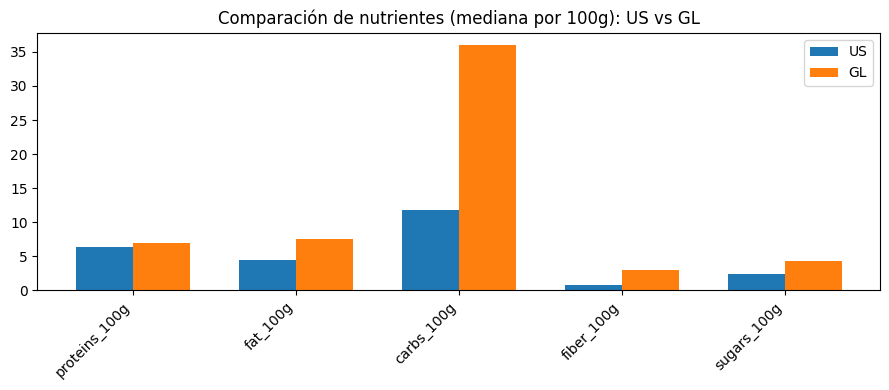

In [152]:
#Quitamos las kcals para analizar los nutrientes y que sea más legible el grafico

cols_plot = ["proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

labels = cols_plot
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9,4))
plt.bar(x - width/2, resumen.loc[cols_plot, "US_median"].values, width, label="US")
plt.bar(x + width/2, resumen.loc[cols_plot, "GL_median"].values, width, label="GL")
plt.xticks(x, labels, rotation=45, ha="right")
plt.title("Comparación de nutrientes (mediana por 100g): US vs GL")
plt.legend()
plt.tight_layout()
plt.show()

In [153]:
#Aunque parece algo descabellado, debemos de tener en cuenta que GL está basado en alimentos registrados de todo el mundo
#Hasta aquí no podemos sacar ninguna conclusión para nuestro análisis, sin embargo, hemos limpiado y categorizado lo alimentos
#que queremos: los productos envasados.

#Por otro lado, hemos creado una serie de reglas nutricionales, con rangos lógicos y fiables, verificándolo con los gráficos.
#también hemos estandarizado las medidas a 100 g para asegurarnos de que todo es comparable.

In [154]:
gl_scores = gl_pack.copy()

gl_scores["nutriscore"] = gl_scores["nutriscore_grade"].astype("string").str.upper()
gl_scores.loc[~gl_scores["nutriscore"].isin(list("ABCDE")), "nutriscore"] = np.nan

gl_scores["nova_group"] = pd.to_numeric(gl_scores["nova_group"], errors="coerce")

gl_scores = gl_scores.dropna(subset=["nutriscore","nova_group"]).copy()
gl_scores["nova_group"] = gl_scores["nova_group"].astype(int)

print(gl_scores.shape)
gl_scores[["nutriscore","nova_group"]].head()


(4178, 26)


,nutriscore,nova_group
2,A,1
3,A,1
5,B,3
6,A,1
7,A,3


In [155]:
tabla = pd.crosstab(gl_scores["nutriscore"], gl_scores["nova_group"], normalize="index")
tabla

nova_group,1,2,3,4
nutriscore,,,,
A,0.382429,0.003876,0.276486,0.337209
B,0.183471,0.076033,0.266116,0.474380
C,0.072957,0.018482,0.283074,0.625486
D,0.029172,0.022170,0.301050,0.647608
E,0.008753,0.099562,0.141138,0.750547


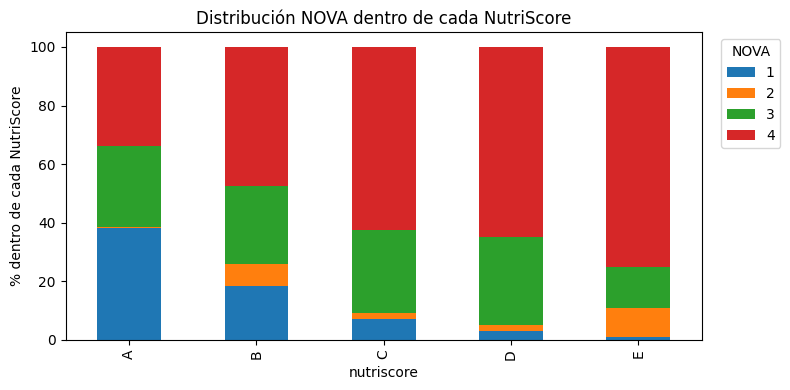

In [156]:
(tabla * 100).plot(kind="bar", stacked=True, figsize=(8,4))
plt.ylabel("% dentro de cada NutriScore")
plt.title("Distribución NOVA dentro de cada NutriScore")
plt.legend(title="NOVA", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [157]:
#En este gráfico vemos que las escalas de Nutriscore y NOVA no están alineadas. Por ejemplo, 
#un alimento de Nutriscore A, puede estar categorizado como nivel cuatro dentro de la escala Nova.
#esto muestra que puede haber alimentos con una buena nota nutricional, según el Nootric, pero pueden
#seguir siendo ultraprocesados. Sin embargo, así que vemos que van aumentando en proporción y hay más relación
#en alimentos con mala nota nutriciona (un Nutriscore E) y ultraprocesados.

In [158]:
#ahora para resolver y plantear nuestro problema de negocio, vamos a ver las incoherencias que hay entre
#el Nutriscore y el NOVA basándonos en que los productos ultraprocesados generalmente no son buenos para la salud
#aunque estos tengan un Nutriscore A. Para ello compararemos alimentos que el Nutriscore considera bueno, pero que son ultraprocesados

In [159]:
ab = gl_scores[gl_scores["nutriscore"].isin(["A","B"])].copy()

contradiccion = (ab["nova_group"] == 4).mean() * 100
print("Porcentaje de A/B que son NOVA 4:", round(contradiccion, 1), "%")

Porcentaje de A/B que son NOVA 4: 39.7 %


In [160]:
#a continuación, segaremos aquellos en los que ambos medidores están de acuerdo en que son alimentos nutricionales
#y poco o nada procesados. Esto nos ayudará a sesgar alimentos para recomendar en nuestra aplicación.
#partiremos de la base de que todos son no recomendables, a no ser que sus puntuaciones estén en A o B(en Nutriscore)
# y 1 o 2 (en NOVA)

In [161]:
gl_scores["decision"] = "NO RECOMENDABLES"

gl_scores.loc[
    gl_scores["nutriscore"].isin(["A","B"]) & gl_scores["nova_group"].isin([1,2]),
    "decision"
] = "ALTAMENTE RECOMENDABLES"

gl_scores.loc[
    gl_scores["nutriscore"].isin(["A","B"]) & gl_scores["nova_group"].isin([3,4]),
    "decision"
] = "REVISAR/PUNTUALMENTE"

gl_scores["decision"].value_counts()

decision
NO RECOMENDABLES           2799
REVISAR/PUNTUALMENTE        923
ALTAMENTE RECOMENDABLES     456
Name: count, dtype: int64

In [162]:
(gl_scores["decision"].value_counts(normalize=True) * 100).round(1)

decision
NO RECOMENDABLES           67.0
REVISAR/PUNTUALMENTE       22.1
ALTAMENTE RECOMENDABLES    10.9
Name: proportion, dtype: float64

In [163]:
cols_n = ["energy_kcal_100g","proteins_100g","fat_100g","carbs_100g","fiber_100g","sugars_100g"]

gl_scores.groupby("decision")[cols_n].median()

,energy_kcal_100g,proteins_100g,fat_100g,carbs_100g,fiber_100g,sugars_100g
decision,,,,,,
ALTAMENTE RECOMENDABLES,140.000000,4.5,2.0,4.80,3.000,1.70
NO RECOMENDABLES,383.000000,6.2,15.0,35.00,2.805,7.10
REVISAR/PUNTUALMENTE,172.042065,8.5,2.7,14.15,4.700,2.86


Al combinar **NutriScore + NOVA**, la regla separa tres grupos con perfiles claramente distintos:

- **Altamente recomendables:** concentra productos menos calóricos y con menos grasa/azúcar.  
- **No recomendables:** agrupa opciones más densas en energía, grasa y azúcar.  
- **Puntualmente:** requiere revisión porque puede tener buen perfil de macros (proteína/fibra) pero mayor procesado.